In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import qiskit_aer as qa
import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer.noise import NoiseModel, pauli_error
from tqdm import tqdm

In [ ]:
# Initialize 5 qubits and 2 bits
qc = QuantumCircuit(5, 3)

# Apply CNOT to first 3 qubits to create a 3-qubit repetition code
qc.cx(0, 1)
qc.cx(1, 2)

# Apply idle gates for noise model
qc.id(0)
qc.id(1)
qc.id(2)
# Create a noise model with bit-flip errors
p = 0.2
bitflip = pauli_error([('X', p), ('I', 1 - p)])
noise_model = NoiseModel()

# Noise, measurement, and error correction loop
numiterations = 10

for q in range(3):
    noise_model.add_quantum_error(bitflip, ['id'], [q])

    # Measure stabilizer Z1Z2 by creating ancilla qubit on 4th qubit
    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.measure(3, 0)

    # Measure stabilizer Z2Z3 by creating ancilla qubit on 5th qubit
    qc.cx(1, 4)
    qc.cx(2, 4)
    qc.measure(4, 1)

    if qc.cregs[0] == 0b10:
        qc.x(0)
    elif qc.cregs[0] == 0b11:
        qc.x(1)
    elif qc.cregs[0] == 0b01:
        qc.x(2)

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

# Simulate the circuit with noise model (errors occur probabilistically during simulation)
backend = qa.Aer.get_backend('qasm_simulator')
job = backend.run(qc, shots=10000, noise_model=noise_model)
result = job.result()
counts = result.get_counts(qc)
print("Simulation result with probabilistic errors:", counts)











Simulation result with probabilistic errors: {'000': 10000}


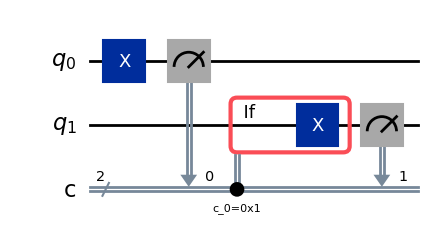

In [87]:
qreg = QuantumRegister(2, 'q')
creg = ClassicalRegister(2, 'c')
qc = QuantumCircuit(qreg, creg)
qc.x(qreg[0])
qc.measure(qreg[0], creg[0])
# Use if_test context manager for conditional gates (newer Qiskit syntax)
with qc.if_test((creg[0], 1)):
    qc.x(qreg[1])
qc.measure(qreg[1], creg[1])
qc.draw('mpl')

In [9]:
# Parameters
numiterations = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
bitflipprobs = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
nshots = 1000
resultsmat = np.zeros((len(numiterations), len(bitflipprobs)))

for ni in tqdm(range(len(numiterations))):
    for p in range(len(bitflipprobs)):
        bitflipprob = bitflipprobs[p]
        numiter = numiterations[ni]

        # Create circuit register with 5 qubits and 5 classical bits
        qreg = QuantumRegister(5, 'q')
        creg = ClassicalRegister(5, 'c')
        qc = QuantumCircuit(qreg, creg)

        # Create a noise model with bit-flip errors
        bitflip = pauli_error([('X', bitflipprob), ('I', 1 - bitflipprob)])
        noise_model = NoiseModel()
        # Apply noise to the first 3 data qubits
        for q in range(3):
            pass
            noise_model.add_quantum_error(bitflip, ['id'], [q])

        # Apply CNOT to first 3 qubits to create a 3-qubit repetition code
        qc.cx(qreg[0], qreg[1])
        qc.cx(qreg[1], qreg[2])

        # Iterations loop
        for n in range(numiter):
            # Apply idle gates for noise model
            qc.id(qreg[0])
            qc.id(qreg[1])
            qc.id(qreg[2])
            # Measure stabilizer Z1Z2 by creating ancilla qubit on 4th qubit
            qc.cx(qreg[0], qreg[3])
            qc.cx(qreg[1], qreg[3])
            qc.measure(qreg[3], creg[3])    
            # Measure stabilizer Z2Z3 by creating ancilla qubit on 5th qubit
            qc.cx(qreg[1], qreg[4])
            qc.cx(qreg[2], qreg[4])
            qc.measure(qreg[4], creg[4])

            # Error correction
            with qc.if_test((creg[3], 1)):
                with qc.if_test((creg[4], 0)):
                    qc.x(qreg[0])
            with qc.if_test((creg[3], 1)):
                with qc.if_test((creg[4], 1)):
                    qc.x(qreg[1])
            with qc.if_test((creg[3], 0)):
                with qc.if_test((creg[4], 1)):
                    qc.x(qreg[2])

            # Reset ancilla qubits (reset to |0⟩ state)
            # Note: reset() may not work perfectly with noise, so we'll manually reset
            # by measuring and conditionally applying X if needed
            qc.measure(qreg[3], creg[3])
            with qc.if_test((creg[3], 1)):
                qc.x(qreg[3])
            qc.measure(qreg[4], creg[4])
            with qc.if_test((creg[4], 1)):
                qc.x(qreg[4])

        qc.measure(qreg[0], creg[0])
        qc.measure(qreg[1], creg[1])
        qc.measure(qreg[2], creg[2])
        qc.measure(qreg[3], creg[3])
        qc.measure(qreg[4], creg[4])



        # Simulate the circuit 10000 times (shots=10000) using Qiskit Aer
        backend = qa.Aer.get_backend('qasm_simulator')
        job = backend.run(qc, shots=nshots, noise_model=noise_model)
        result = job.result()
        counts = result.get_counts(qc)
        try:
            resultsmat[ni, p] = counts['00000'] / nshots
        except:
            resultsmat[ni, p] = 0
#qc.draw('mpl')

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [03:56<00:00, 21.51s/it]


In [10]:
# Save the resultsmat matrix as a CSV file
np.savetxt("/home/kale-chen/Downloads/resultsmat.csv", resultsmat, delimiter=",")


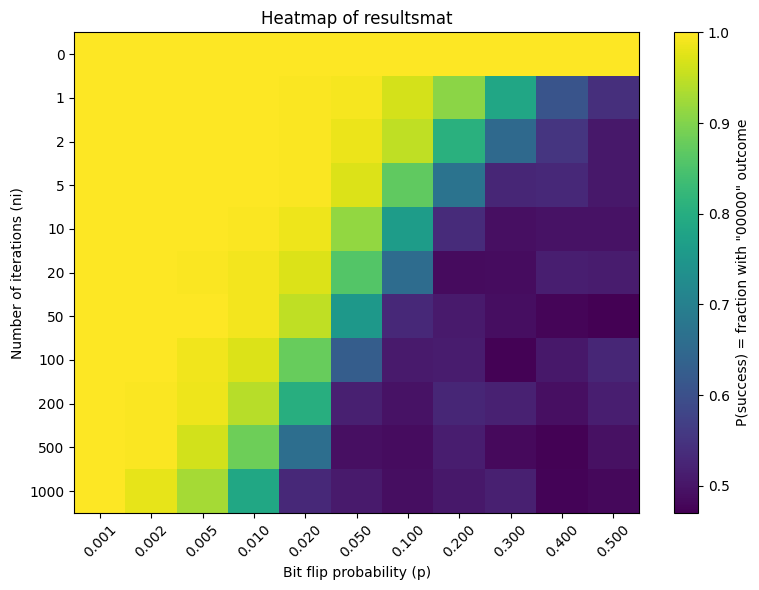

In [13]:
plt.figure(figsize=(8, 6))
im = plt.imshow(resultsmat, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(im, label='P(success) = fraction with "00000" outcome')
plt.xlabel('Bit flip probability (p)')
plt.ylabel('Number of iterations (ni)')
plt.title('Heatmap of resultsmat')

# Set x and y ticks and labels to the actual bitfliprobs and numiterations entries
plt.xticks(ticks=range(len(bitflipprobs)), labels=[f"{p:.3f}" for p in bitflipprobs], rotation=45)
plt.yticks(ticks=range(len(numiterations)), labels=[str(ni) for ni in numiterations])

plt.tight_layout()
plt.show()


In [ ]:
# Simulate the circuit 1000 times (shots=1000) using Qiskit Aer
backend = qa.Aer.get_backend('qasm_simulator')
job = backend.run(qc, shots=1000)
result = job.result()
counts = result.get_counts(qc)
print(counts)



fig = qc.draw('mpl')  # returns a matplotlib.figure.Figure
fig  # In a notebook, just returning the figure displays it

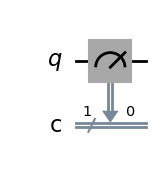

In [11]:

# Create a 1-qubit circuit
qc = QuantumCircuit(1, 1)
qc.measure(0, 0)  # Measure in Z basis

# Matplotlib drawer
fig = qc.draw('mpl')  # returns a matplotlib.figure.Figure
fig  # In a notebook, just returning the figure displays it

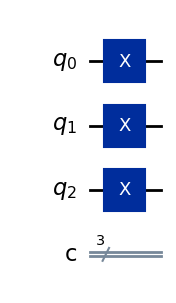

In [100]:


# Create a quantum register with 3 qubits for the repetition code
qreg = QuantumRegister(3, 'q')
creg = ClassicalRegister(3, 'c')


# Example: Create logical |1⟩_L
qc_logical_1 = QuantumCircuit(qreg, creg)
qc_logical_1.x(qreg[0])  # Apply X to first qubit
qc_logical_1.x(qreg[1])  # Apply X to second qubit
qc_logical_1.x(qreg[2])  # Apply X to third qubit

qc_logical_1.draw('mpl')




In [14]:
# Measure each qubit in the Z (computational) basis and store the results in the classical register
qc.measure(qreg[0], creg[0])
qc.measure(qreg[1], creg[1])
qc.measure(qreg[2], creg[2])

qc_logical_1.measure(qreg[0], creg[0])
qc_logical_1.measure(qreg[1], creg[1])
qc_logical_1.measure(qreg[2], creg[2])

qc_logical_1.draw('mpl')

CircuitError: 'Bit \'<Qubit register=(3, "q"), index=0>\' is not in the circuit.'